Here, I want to explore how feature transformation can affect the performance of a Linear Regression model.

Linear Regression assumes a linear relationship between the features and the target, but the data we work with doesn't always follow that assumption. So, what happens if we transform the data first?

In this notebook, I'll start with a baseline Linear Regression model, then experiment with log transformation. Then I'll compare the results and see whether this transformations can help the model perform better.

Let's see what happens!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('/kaggle/input/datasets/vipullrathod/fish-market/Fish.csv')
df.head(3)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [4]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


**Target**: Weight

In [5]:
target_column = "Weight"

numerical_columns = (
    df.select_dtypes(include=["number"])
      .columns
      .drop(target_column)
)

print(numerical_columns)

Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')


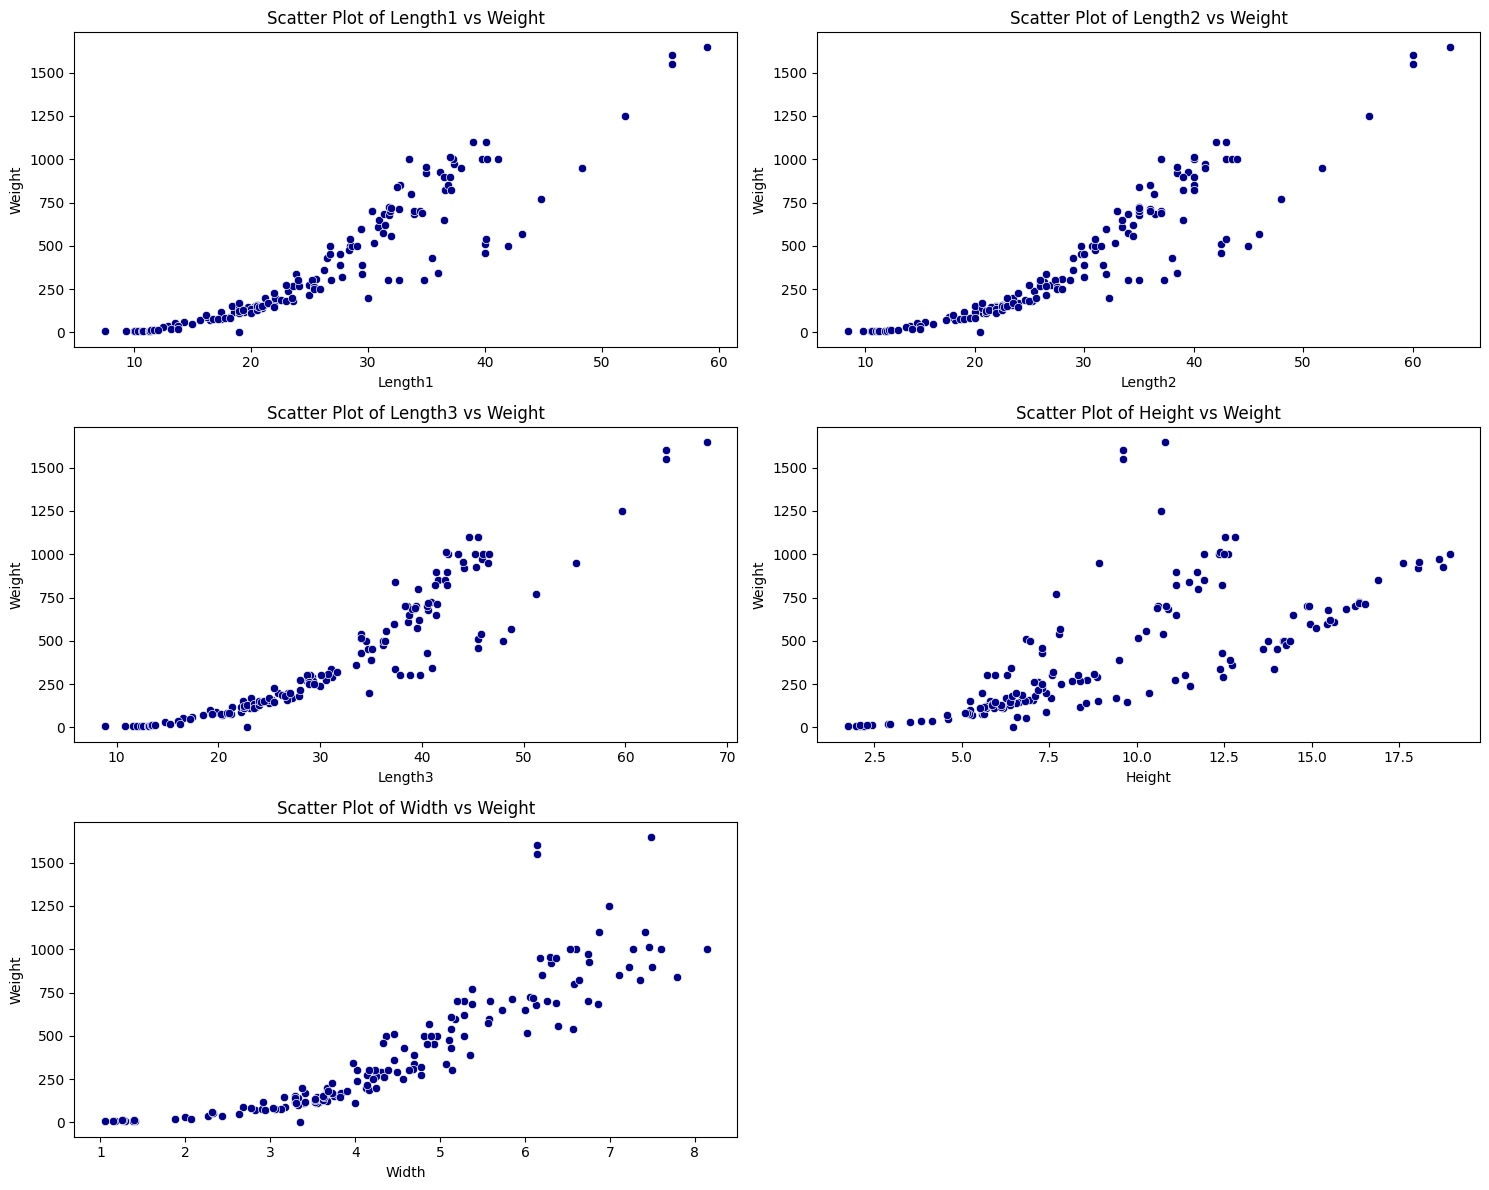

In [6]:
n_cols = 2
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=df[col], y=df['Weight'], color='darkblue')
    plt.title(f"Scatter Plot of {col} vs Weight")
    plt.xlabel(col)
    plt.ylabel("Weight")

plt.tight_layout()
plt.show()

There is (very lil) linearity between target and features. What to do?: Try transform.

# **Log Transformation**

Let's try applying a log transformation to both the features and the target, then compare the results. Could this make the relationship more linear?

In [7]:
X_log = np.log1p(df["Length1"])

<Axes: xlabel='Length1', ylabel='Weight'>

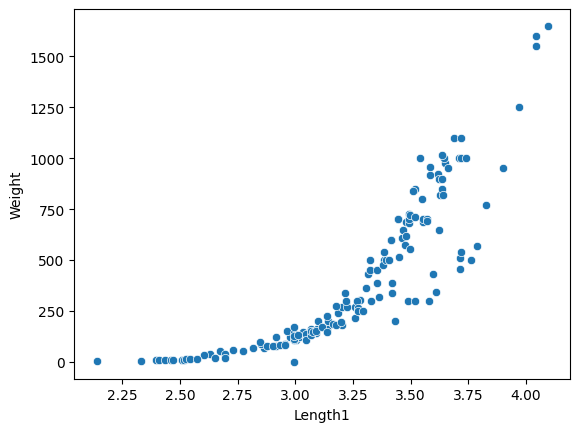

In [8]:
sns.scatterplot(x=X_log, y=df["Weight"])

<Axes: xlabel='Length1', ylabel='Weight'>

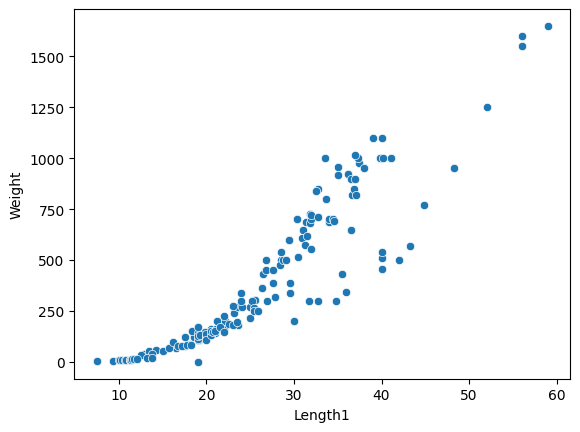

In [9]:
sns.scatterplot(x=df["Length1"], y=df["Weight"])

In [10]:
y_log = np.log1p(df["Weight"])

<Axes: xlabel='Length1', ylabel='Weight'>

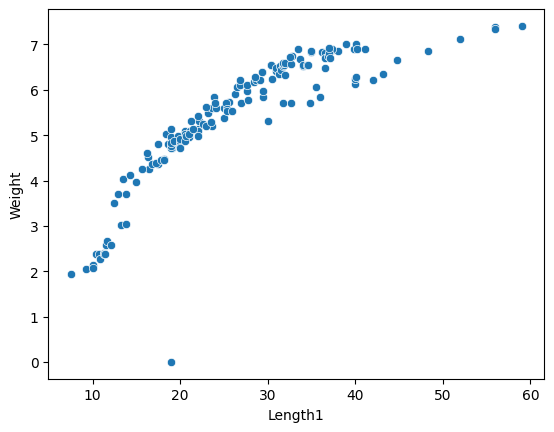

In [11]:
sns.scatterplot(x=df["Length1"], y=y_log)

<Axes: xlabel='Length1', ylabel='Weight'>

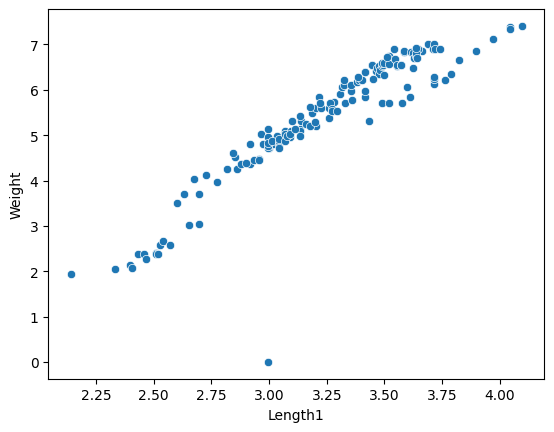

In [12]:
sns.scatterplot(x=X_log, y=y_log)

Whoa, it turns out that applying a log transformation to both this feature and the target makes the relationship much more linear. 

Nice! Now, let's apply the same transformation to all the features and see how it affects the results.


In [13]:
df_log_transform = df.copy()

log_features = numerical_columns

df_log_transform[log_features] = np.log1p(
    df_log_transform[log_features]
)

df_log_transform["Weight"] = np.log1p(
    df_log_transform["Weight"]
)

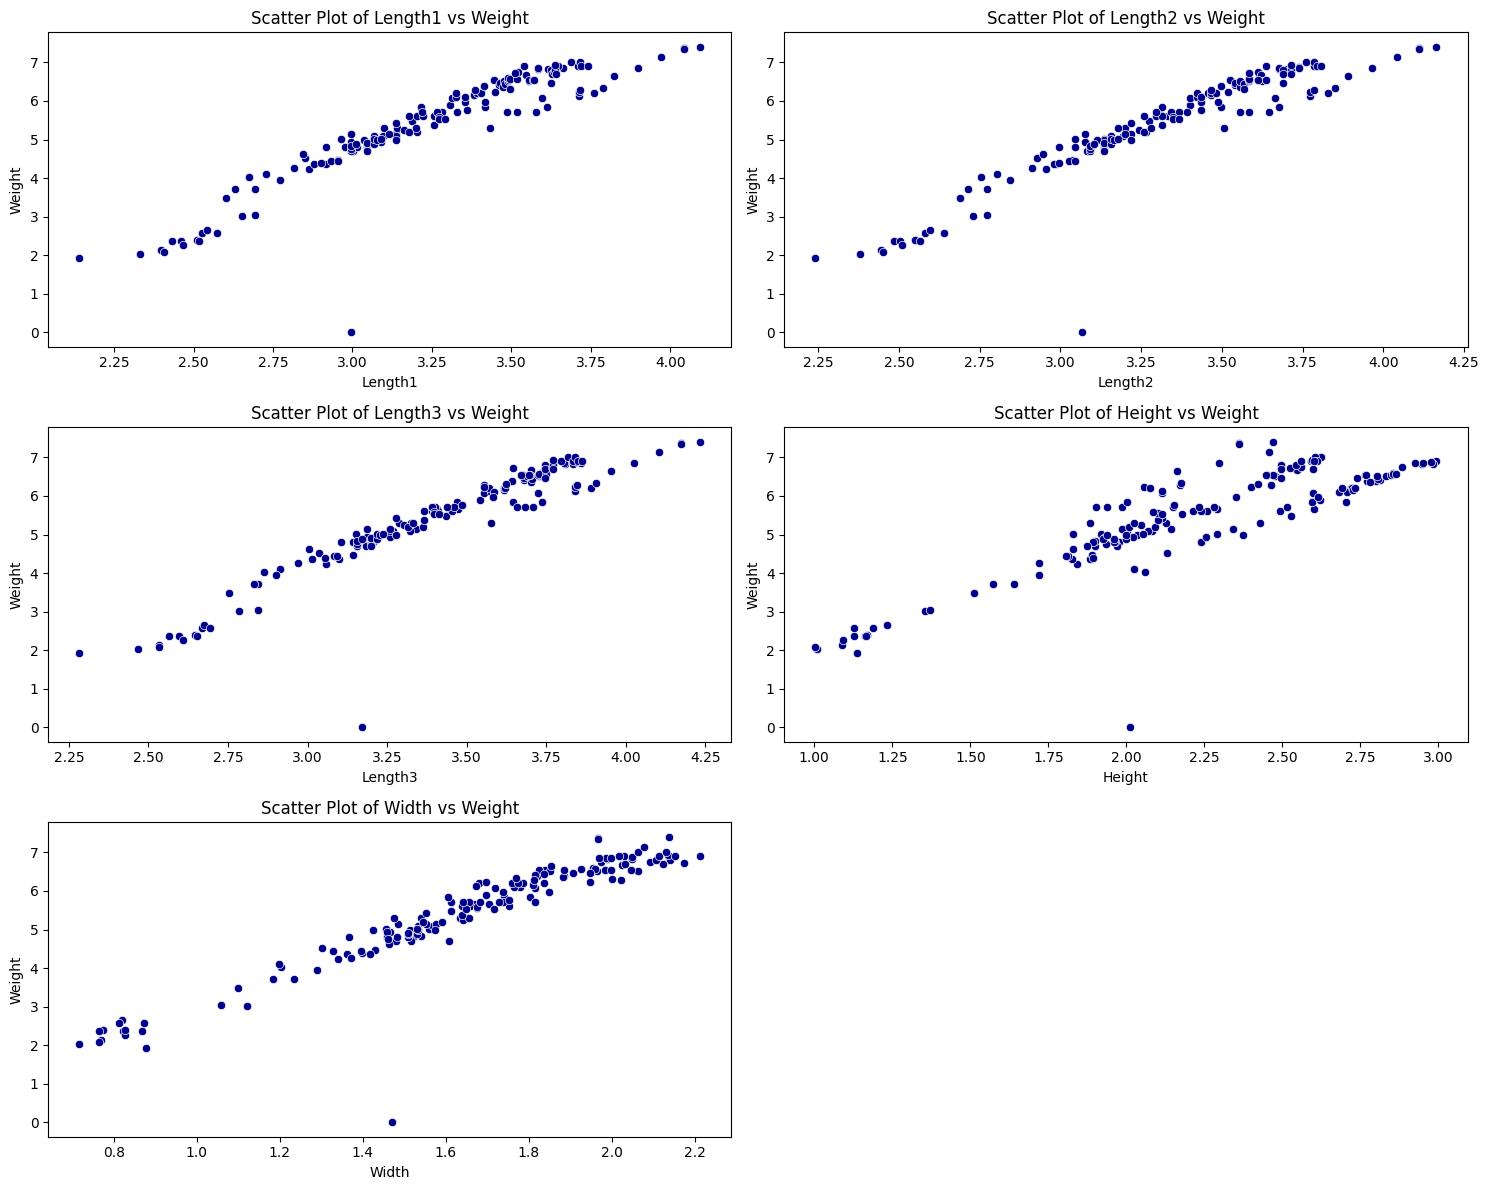

In [14]:
n_cols = 2
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=df_log_transform[col], y=df_log_transform['Weight'], color='darkblue')
    plt.title(f"Scatter Plot of {col} vs Weight")
    plt.xlabel(col)
    plt.ylabel("Weight")

plt.tight_layout()
plt.show()

Linear! Approximately! As expected :D

# **Model**

## **Baseline**

In [15]:
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(df[numerical_columns], df['Weight'], test_size=0.1, random_state=38)

In [16]:
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_baseline, y_train_baseline)

LinearRegression()

In [17]:
y_test_baseline_pred = lr_baseline.predict(X_test_baseline)

r2_test_baseline = r2_score(y_test_baseline, y_test_baseline_pred)
mae_test_baseline = mean_absolute_error(y_test_baseline, y_test_baseline_pred)

print(f"R2 Test Baseline : {r2_test_baseline}")
print(f"MAE Test Baseline : {mae_test_baseline}")

R2 Test Baseline : 0.8812077654166748
MAE Test Baseline : 102.56850777996539


## **Log Tranformation**

Now, let's train the Linear Regression model using both the features and the target after applying a log transformation.

In [18]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(df_log_transform[numerical_columns], df_log_transform['Weight'], test_size=0.1, random_state=38)

In [19]:
lr_log = LinearRegression()
lr_log.fit(X_train_log, y_train_log)

LinearRegression()

In [20]:
y_test_log_pred = lr_log.predict(X_test_log)

y_test_log_pred = np.expm1(y_test_log_pred)
y_test_log = np.expm1(y_test_log)

r2_test_log = r2_score(y_test_log, y_test_log_pred)
mae_test_log = mean_absolute_error(y_test_log, y_test_log_pred)

print(f"R2 Test Log Transformation: {r2_test_log}")
print(f"MAE Test Log Transformation: {mae_test_log}")

R2 Test Log Transformation: 0.9686184846337736
MAE Test Log Transformation: 44.22618084392


The results are much better than the baseline, which shows that transforming the data can make a big difference in Linear Regression. One thing worth trying is log transformation, either on the features alone or on both the features and the target.

For this dataset, applying the log transformation to both gave a pretty significant improvement over the baseline.